# Physics Informed Neural Networks (PINNs) - 2D Wave Equation 
Training Neural Network to converge towards a well-defined solution of a PDE by way of minimising for the residuals across the spatio-temporal domain. Initial and Boundary conditions are met by introducing them into the loss function along with the PDE residuals. 

Numerical Method - Spectral Solver using FFT. <br>
Code taken from [this tutorial.](http://people.bu.edu/andasari/courses/numericalpython/Week12Lecture21/Spectral_wave2.py) <br>

Equation: 

```
u_tt = u_xx + u_yy on [-1,1] x [-1,1] 
```

Dirichlet Boundary Conditions : 
```
u=0
```

Initial Distribution :
```
 u(x,y,t=0) = exp(-40(x-0.4)^2 + y^2)
 ```

Initial Velocity Condition : 
```
u_t(x,y,t=0) = 0
```


In [1]:
#Building the numerical solution by solving the Wave Equation using a spectral solver implemented on numpy.
# The solution will not form the training data but will be used for comparing against the PINN solution. 

import numpy as np
from scipy import interpolate
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.interpolate import RegularGridInterpolator

class WaveEquation:
    
    def __init__(self, N, T):
        self.N = N
        self.T = T
        self.x0 = -1.0
        self.xf = 1.0
        self.y0 = -1.0
        self.yf = 1.0
        self.initialization()
        self.initCond()
        
        
    def initialization(self):
        k = np.arange(self.N + 1)
        self.x = np.cos(k*np.pi/self.N)
        self.y = self.x.copy()
        self.xx, self.yy = np.meshgrid(self.x, self.y)
        
        self.dt = 6/self.N**2
        self.plotgap = round((1/3)/self.dt)
        self.dt = (1/3)/self.plotgap
        
        
    def initCond(self):
        self.vv = np.exp(-40*((self.xx-0.4)**2 + self.yy**2))
        self.vvold = self.vv.copy()
        
        
    def solve(self):
        u_list = []
        fig = plt.figure()

        tc = 0
        nstep = round(self.T / self.dt) + 1

        # 创建目标插值网格
        xxx = np.arange(self.x0, self.xf + 1 / 16, 1 / 16)
        yyy = np.arange(self.y0, self.yf + 1 / 16, 1 / 16)
        xxf, yyf = np.meshgrid(xxx, yyy, indexing='ij')
        interp_points = np.stack([xxf.flatten(), yyf.flatten()], axis=-1)

        ii = np.arange(1, self.N)

        while tc < nstep:
            # 替代 interp2d 的插值方法
            interp_func = RegularGridInterpolator((self.x, self.y), self.vv, method='linear')
            Z = interp_func(interp_points).reshape(xxf.shape)

            uxx = np.zeros((self.N + 1, self.N + 1))
            uyy = np.zeros((self.N + 1, self.N + 1))

            for i in range(1, self.N):
                v = self.vv[i, :]
                V = np.hstack((v, np.flipud(v[ii])))
                U = np.fft.fft(V).real

                r1 = np.arange(self.N)
                r2 = 1j * np.hstack((r1, 0, -r1[:0:-1])) * U
                W1 = np.fft.ifft(r2).real

                s1 = np.arange(self.N + 1)
                s2 = np.hstack((s1, -s1[self.N - 1:0:-1]))
                s3 = -s2**2 * U
                W2 = np.fft.ifft(s3).real

                uxx[i, ii] = W2[ii] / (1 - self.x[ii]**2) - self.x[ii] * W1[ii] / (1 - self.x[ii]**2)**(3/2)

            for j in range(1, self.N):
                v = self.vv[:, j]
                V = np.hstack((v, np.flipud(v[ii])))
                U = np.fft.fft(V).real

                r1 = np.arange(self.N)
                r2 = 1j * np.hstack((r1, 0, -r1[:0:-1])) * U
                W1 = np.fft.ifft(r2).real

                s1 = np.arange(self.N + 1)
                s2 = np.hstack((s1, -s1[self.N - 1:0:-1]))
                s3 = -s2**2 * U
                W2 = np.fft.ifft(s3).real

                uyy[ii, j] = W2[ii] / (1 - self.y[ii]**2) - self.y[ii] * W1[ii] / (1 - self.y[ii]**2)**(3/2)

            vvnew = 2 * self.vv - self.vvold + self.dt**2 * (uxx + uyy)
            self.vvold = self.vv.copy()
            self.vv = vvnew.copy()

            tc += 1
            u_list.append(Z)

        return np.asarray(u_list)

        
    
def main(N, T):
    simulator = WaveEquation(N, T) 
    u_sol = simulator.solve()
    return u_sol

    
if __name__ == "__main__":
    time_end = 1 #Upto how many seconds we would like to simulate. 
    N = 30 #Spatial Discretisation. 
    dt =  6/N**2 #N and dt are fixed for ensuring numerical stability. 
    k = 30 + 1

    u_sol = main(N, time_end)    
    

    lb = np.asarray([-1.0, -1.0, 0]) #[x, y, t] Lower Bounds of the domain
    ub = np.asarray([1.0, 1.0, time_end]) #Upper Bounds of the domain/ 
    
    x = np.arange(-1, 1+1/16, 1/16)
    y = x.copy()
    t = np.arange(lb[2], ub[2]+dt, dt)
    
    xx, yy = np.meshgrid(x, y)
    u_ic = np.exp(-40*((xx-0.4)**2 + yy**2)) #Initial Gaussian Distribution. 
    
    U_sol = u_sol

    grid_length = len(x)
    
    #Storing the problem and solution information.
    df_dict = {'x': x,
               'y': y,
               't': t,
               'lower_range': lb,
               'upper_range': ub,
               'U_sol': U_sol}
    

<Figure size 640x480 with 0 Axes>

In [2]:
import os
import time
from tqdm import tqdm 
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt 
%matplotlib inline
import operator
from functools import reduce 

from pyDOE import lhs
import torch
import torch.nn as nn

# %
default_device = "cuda" if torch.cuda.is_available() else "cpu"

dtype=torch.float32
torch.set_default_dtype(dtype)

def torch_tensor_grad(x, device):
    if device == 'cuda':
        x = torch.cuda.FloatTensor(x)
    else:
        x = torch.FloatTensor(x)
    x.requires_grad = True
    return x 

def torch_tensor_nograd(x, device):
    if device == 'cuda':
        x = torch.cuda.FloatTensor(x)
    else:
        x = torch.FloatTensor(x)
    x.requires_grad = False
    return x 

In [3]:
# Setting the random seed. 
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)

In [4]:
# Fully Connected Network or a Multi-Layer Perceptron as the PINN. 
class MLP(nn.Module):
    def __init__(self, in_features, out_features, num_layers, num_neurons, activation=torch.tanh):
        super(MLP, self).__init__()

        self.in_features = in_features
        self.out_features = out_features
        self.num_layers = num_layers
        self.num_neurons = num_neurons

        self.act_func = activation

        self.layers = nn.ModuleList()

        self.layer_input = nn.Linear(self.in_features, self.num_neurons)

        for ii in range(self.num_layers - 1):
            self.layers.append(nn.Linear(self.num_neurons, self.num_neurons))
        self.layer_output = nn.Linear(self.num_neurons, self.out_features)

    def forward(self, x):

        x_temp = self.act_func(self.layer_input(x))
        for dense in self.layers:
            x_temp = self.act_func(dense(x_temp))
        x_temp = self.layer_output(x_temp)
        return x_temp

    def count_params(self):
        c = 0
        for p in self.parameters():
            c += reduce(operator.mul, list(p.size()))
        return c 
      

#Setting up a derivative function that goes through the graph and calculates via chain rule the derivative of u wrt x 
deriv = lambda u, x: torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u), create_graph=True, allow_unused=True)[0]


In [5]:
#Setting up an instance of the Resnet with the needed architecture. 
npde_net = MLP(in_features=3, out_features=1, num_layers=5, num_neurons=100)
npde_net = npde_net.to(default_device)


In [6]:
from pyDOE import lhs

#Specifying the Domain of Interest. 
x_range = [-1.0, 1.0]
y_range = [-1.0, 1.0]
t_range = [0.0, time_end]
D = 1.0

lb = np.asarray([x_range[0], y_range[0], t_range[0]])
ub = np.asarray([x_range[1], y_range[1], t_range[1]])

#Fucnction to sample collocation points across the spatio-temporal domain using a Latin Hypercube
def LHS_Sampling(N):
    return lb + (ub-lb)*lhs(3, N)


In [8]:

#Domain Loss Function - measuring the deviation from the PDE functional. 
def pde(X):

    x = X[:, 0:1]
    y = X[:, 1:2]
    t = X[:, 2:3]
    u = npde_net(torch.cat([x,y,t],1))

    u_x = deriv(u, x)
    u_xx = deriv(u_x, x)
    u_y = deriv(u, y)
    u_yy = deriv(u_y, y)
    u_t = deriv(u, t)
    u_tt = deriv(u_t, t)
    
    pde_loss = u_tt - (u_xx + u_yy)

    return pde_loss.pow(2).mean()



#Boundary Loss Function - measuring the deviation from boundary conditions for f(x_lim, y_lim, t)
def boundary(X):

    u = npde_net(X)
    bc_loss = u - 0 

    return bc_loss.pow(2).mean()

#Initial Velocity Conditions :
def initial_velocity(X):

    x = X[:, 0:1]
    y = X[:, 1:2]
    t = X[:, 2:3]
    u = npde_net(torch.cat([x,y,t],1))

    u_t = deriv(u, t)
    initial_cond_loss = u_t - 0

    return initial_cond_loss.pow(2).mean()


#Reconstruction Loss Function - measuring the deviation fromt the actual output. Used to calculate the initial loss
def reconstruction(X, Y):
    u = npde_net(X)
    recon_loss = u-Y
    return recon_loss.pow(2).mean()


In [9]:
#Normalisation Strategies

#Range Normalisation
def min_max_norm(x):
    return 2*(x-np.min(x))/(np.max(x)-np.min(x)) - 1

# Z-Score Normalisation 
def z_score(x):
    return (x-np.mean(x)) / np.std(x)

#No Normalisation
def identity(x):
  return x


In [10]:
#Samples taken from each region for optimisation purposes. 
N_i = 1000 #Initial
N_b = 1000 #Boundary
N_f = 20000 #Domain

In [11]:
#Prepping the inputs and outputs for the testing against the actual solution. 
u = np.asarray(u_sol)
X, Y = np.meshgrid(x, y)
XY_star = np.hstack((X.flatten()[:,None], Y.flatten()[:,None]))
T_star = np.expand_dims(np.repeat(t, len(XY_star)), 1)
X_star_tiled = np.tile(XY_star, (len(t), 1))

X_star = np.hstack((X_star_tiled, T_star))
u_actual = np.expand_dims(u.flatten(),1)


In [12]:
# Data for Initial Input

X_IC = np.hstack((XY_star, np.zeros(len(XY_star)).reshape(len(XY_star), 1)))
u_IC = u[0].flatten()
u_IC = np.expand_dims(u_IC, 1)

idx = np.random.choice(X_IC.shape[0], N_i, replace=False) 
X_i = X_IC[idx]
u_i = u_IC[idx]

In [13]:
# Data for Boundary Input

X_left = LHS_Sampling(N_b)
X_left[:,0:1] = x_range[0]

X_right = LHS_Sampling(N_b)
X_right[:,0:1] = x_range[1]

X_bottom = LHS_Sampling(N_b)
X_bottom[:,1:2] = y_range[0]

X_top = LHS_Sampling(N_b)
X_top[:,1:2] = y_range[1]

X_b = np.vstack((X_right, X_top, X_left, X_bottom))
np.random.shuffle(X_b) 

In [14]:
#Data for Domain Input
X_f = LHS_Sampling(N_f)


In [15]:
#Converting to tensors 

X_i = torch_tensor_grad(X_i, default_device)
Y_i = torch_tensor_nograd(u_i, default_device)
X_b = torch_tensor_grad(X_b, default_device)
X_f = torch_tensor_grad(X_f, default_device)

/tmp/ipykernel_43283/583996461.py:23: UserWarning: The torch.cuda.*DtypeTensor constructors are no longer recommended. It's best to use methods such as torch.tensor(data, dtype=*, device='cuda') to create tensors. (Triggered internally at ../torch/csrc/tensor/python_tensor.cpp:78.)
  x = torch.cuda.FloatTensor(x)


/data/miniconda3/envs/ai4pde/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at ../aten/src/ATen/cuda/CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


It: 1, Init: 2.691e-02, Bound: 1.426e-02, Domain: 4.372e-05
It: 2, Init: 8.584e-03, Bound: 4.130e-04, Domain: 2.690e-04
It: 3, Init: 1.254e-02, Bound: 6.393e-03, Domain: 5.478e-04
It: 4, Init: 1.253e-02, Bound: 5.821e-03, Domain: 4.187e-04
It: 5, Init: 9.540e-03, Bound: 1.975e-03, Domain: 2.177e-04
It: 6, Init: 8.582e-03, Bound: 1.850e-04, Domain: 8.851e-05
It: 7, Init: 9.577e-03, Bound: 4.320e-04, Domain: 3.098e-05
It: 8, Init: 1.077e-02, Bound: 1.065e-03, Domain: 1.181e-05
It: 9, Init: 1.107e-02, Bound: 1.132e-03, Domain: 6.058e-06
It: 10, Init: 1.051e-02, Bound: 7.007e-04, Domain: 5.245e-06
It: 11, Init: 9.599e-03, Bound: 2.182e-04, Domain: 9.313e-06
It: 12, Init: 8.806e-03, Bound: 5.238e-05, Domain: 1.965e-05
It: 13, Init: 8.410e-03, Bound: 3.197e-04, Domain: 3.603e-05
It: 14, Init: 8.407e-03, Bound: 8.320e-04, Domain: 5.466e-05
It: 15, Init: 8.548e-03, Bound: 1.208e-03, Domain: 6.829e-05
It: 16, Init: 8.584e-03, Bound: 1.206e-03, Domain: 7.147e-05
It: 17, Init: 8.489e-03, Bound: 9

Text(0, 0.5, 'L2 Error')

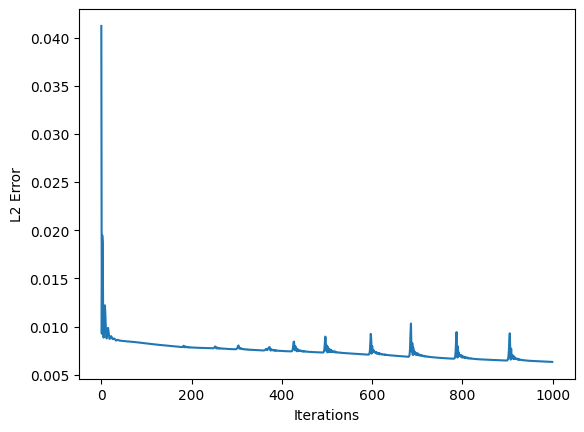

In [16]:
#Training Loop
optimizer = torch.optim.Adam(npde_net.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5000, gamma=0.9)

it=0
epochs = 1000 #Number of Epochs for the training loop. 
loss_list = []

start_time = time.time()
while it < epochs :
    optimizer.zero_grad()

    initial_loss = reconstruction(X_i, Y_i) + initial_velocity(X_i)
    boundary_loss = boundary(X_b)
    domain_loss = pde(X_f)

    loss = initial_loss + boundary_loss + domain_loss   
    loss_list.append(loss.item())
    
    loss.backward()
    optimizer.step()
    scheduler.step()

    it += 1

    print('It: %d, Init: %.3e, Bound: %.3e, Domain: %.3e' % (it, initial_loss.item(), boundary_loss.item(), domain_loss.item()))


train_time = time.time() - start_time
plt.plot(loss_list)
plt.xlabel('Iterations')
plt.ylabel('L2 Error')

In [17]:
#Getting the trained output. 
if default_device == 'cpu':
    with torch.no_grad():
        u_pred = npde_net(torch_tensor_grad(X_star, default_device)).detach().numpy()

else : 
    with torch.no_grad():
        u_pred = npde_net(torch_tensor_grad(X_star, default_device)).cpu().detach().numpy()
        
l2_error = np.mean((u_actual - u_pred)**2)

print('Training Time: %d seconds, L2 Error: %.3e' % (train_time, l2_error))

u_pred = u_pred.reshape(len(u), grid_length, grid_length)

Training Time: 23 seconds, L2 Error: 2.868e-03


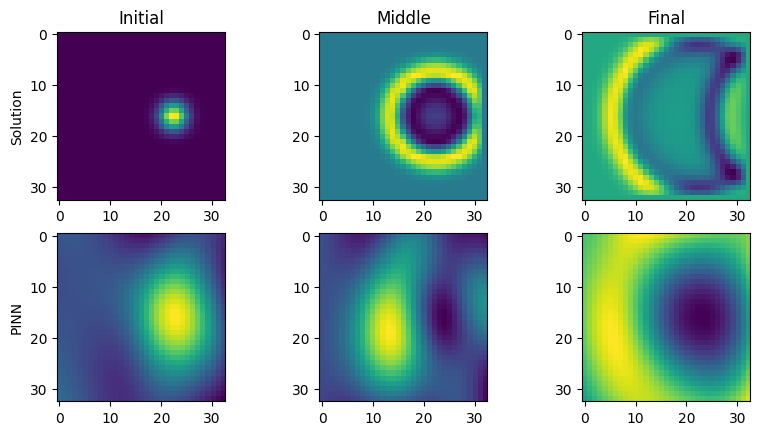

In [19]:
 #Plotting the PINN solution against the Numerical solution. 
 
u_field = u_sol

fig = plt.figure(figsize=plt.figaspect(0.5))
ax = fig.add_subplot(2,3,1)
ax.imshow(u_field[0])
ax.title.set_text('Initial')
ax.set_ylabel('Solution')

ax = fig.add_subplot(2,3,2)
ax.imshow(u_field[int(len(t)/2)])
ax.title.set_text('Middle')

ax = fig.add_subplot(2,3,3)
ax.imshow(u_field[-1])
ax.title.set_text('Final')


u_field = u_pred

ax = fig.add_subplot(2,3,4)
ax.imshow(u_field[0])
ax.set_ylabel('PINN')

ax = fig.add_subplot(2,3,5)
ax.imshow(u_field[int(len(t)/2)])

ax = fig.add_subplot(2,3,6)
ax.imshow(u_field[-1])

正在创建3D动画...
动画已保存为GIF: wave_animation.gif


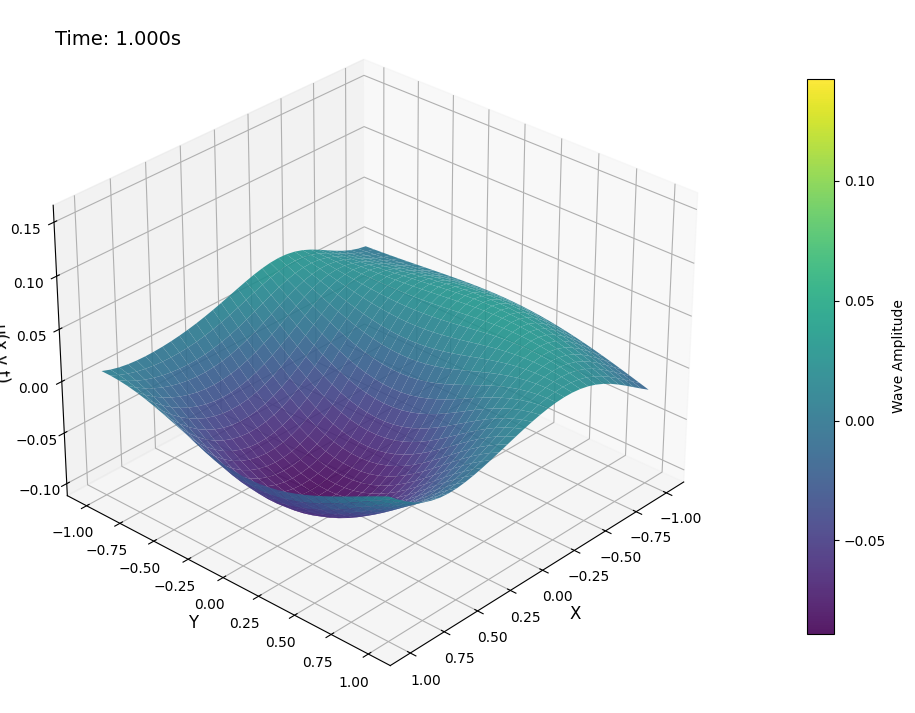


正在创建3D快照...


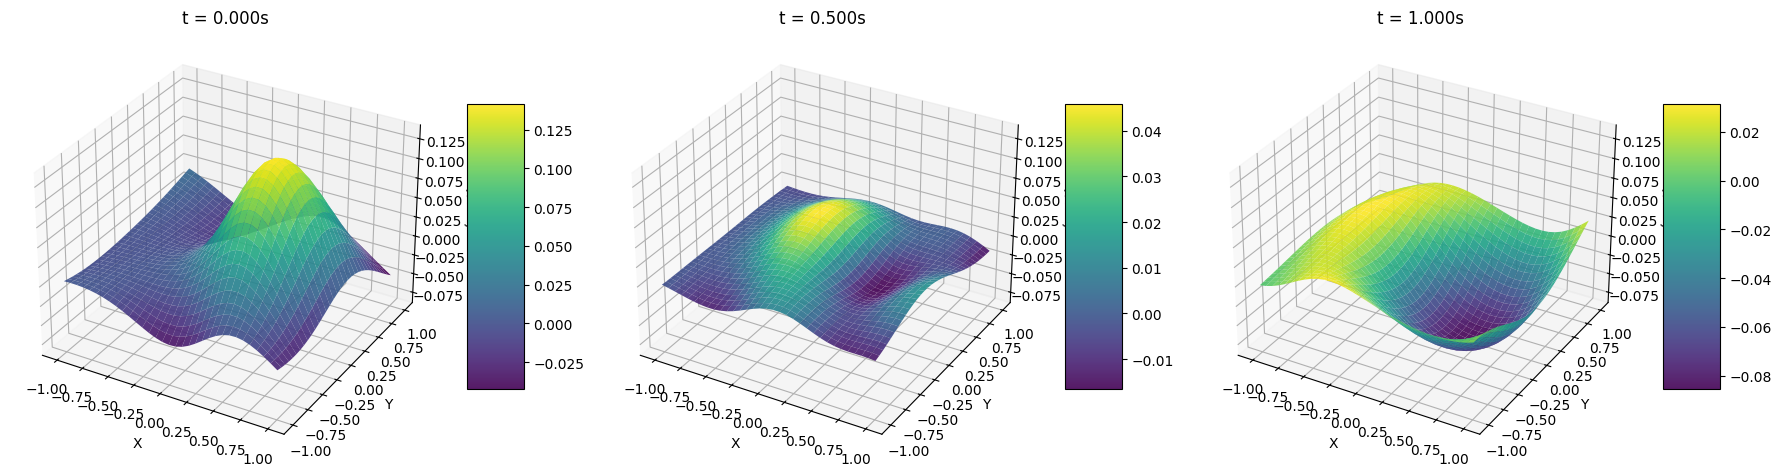


正在创建交互式3D可视化...
Plotly未安装。请使用 'pip install plotly' 安装以使用交互式功能。


In [20]:
# 在原始代码最后添加3D动画可视化
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# 创建3D动画
def create_3d_animation(u_pred, x, y, t, save_path='wave_animation.gif', show_animation=True):
    """
    创建3D波动方程解的动画
    
    参数:
    - u_pred: 预测的波函数值 (时间步数, x网格数, y网格数)
    - x, y: 空间网格点
    - t: 时间点
    - save_path: 保存路径（.gif或.mp4）
    - show_animation: 是否显示动画
    """
    fig = plt.figure(figsize=(12, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    # 创建网格
    X, Y = np.meshgrid(x, y)
    
    # 设置初始视角
    ax.view_init(elev=30, azim=45)
    
    # 设置轴标签和标题
    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_zlabel('u(x,y,t)', fontsize=12)
    
    # 获取数据的最大和最小值，用于固定z轴范围
    vmin, vmax = u_pred.min(), u_pred.max()
    margin = 0.1 * (vmax - vmin)
    ax.set_zlim(vmin - margin, vmax + margin)
    
    # 初始化surface plot
    surf = [ax.plot_surface(X, Y, u_pred[0], cmap='viridis', 
                           linewidth=0, antialiased=True, alpha=0.9,
                           vmin=vmin, vmax=vmax)]
    
    # 添加颜色条
    cbar = fig.colorbar(surf[0], ax=ax, pad=0.1, shrink=0.8)
    cbar.set_label('Wave Amplitude', fontsize=10)
    
    # 时间文本
    time_text = ax.text2D(0.05, 0.95, '', transform=ax.transAxes, fontsize=14)
    
    # 动画更新函数
    def update(frame):
        # 清除之前的surface
        surf[0].remove()
        
        # 绘制新的surface
        surf[0] = ax.plot_surface(X, Y, u_pred[frame], cmap='viridis',
                                 linewidth=0, antialiased=True, alpha=0.9,
                                 vmin=vmin, vmax=vmax)
        
        # 更新时间文本
        time_text.set_text(f'Time: {t[frame]:.3f}s')
        
        # 旋转视角（可选）
        ax.view_init(elev=30, azim=45 + frame * 360 / len(t))
        
        return surf[0], time_text
    
    # 创建动画
    anim = animation.FuncAnimation(fig, update, frames=len(t), 
                                  interval=50, blit=False, repeat=True)
    
    # 保存动画
    try:
        if save_path.endswith('.gif'):
            # 保存为GIF（使用PillowWriter）
            writer = animation.PillowWriter(fps=20)
            anim.save(save_path, writer=writer)
            print(f"动画已保存为GIF: {save_path}")
        elif save_path.endswith('.mp4'):
            # 尝试保存为MP4（需要ffmpeg）
            try:
                writer = animation.FFMpegWriter(fps=20, bitrate=1800)
                anim.save(save_path, writer=writer)
                print(f"动画已保存为MP4: {save_path}")
            except:
                # 如果ffmpeg不可用，退回到GIF
                print("FFmpeg不可用，将保存为GIF格式...")
                save_path = save_path.replace('.mp4', '.gif')
                writer = animation.PillowWriter(fps=20)
                anim.save(save_path, writer=writer)
                print(f"动画已保存为GIF: {save_path}")
    except Exception as e:
        print(f"保存动画时出错: {e}")
        print("将只显示动画而不保存...")
    
    if show_animation:
        plt.show()
    
    return anim

# 创建静态3D图（显示特定时刻）
def plot_3d_snapshots(u_pred, x, y, t, time_indices=None):
    """
    绘制多个时刻的3D波形快照
    
    参数:
    - time_indices: 要绘制的时间索引列表，默认为[0, len(t)//2, -1]
    """
    if time_indices is None:
        time_indices = [0, len(t)//2, -1]
    
    fig = plt.figure(figsize=(18, 6))
    X, Y = np.meshgrid(x, y)
    
    for i, idx in enumerate(time_indices):
        ax = fig.add_subplot(1, len(time_indices), i+1, projection='3d')
        
        surf = ax.plot_surface(X, Y, u_pred[idx], cmap='viridis',
                              linewidth=0, antialiased=True, alpha=0.9)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('u(x,y,t)')
        ax.set_title(f't = {t[idx]:.3f}s')
        
        # 固定z轴范围
        ax.set_zlim(u_pred.min(), u_pred.max())
        
        # 添加颜色条
        fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    
    plt.tight_layout()
    plt.savefig('wave_snapshots_3d.png', dpi=300, bbox_inches='tight')
    plt.show()

# 创建交互式3D图（使用plotly，如果可用）
def create_interactive_3d(u_pred, x, y, t, save_html=True):
    """
    使用plotly创建交互式3D动画（需要安装plotly）
    """
    try:
        import plotly.graph_objects as go
        from plotly.subplots import make_subplots
        
        X, Y = np.meshgrid(x, y)
        
        # 创建frames
        frames = []
        for i in range(len(t)):
            frame = go.Frame(
                data=[go.Surface(x=X, y=Y, z=u_pred[i], 
                               colorscale='Viridis',
                               showscale=True)],
                name=str(i)
            )
            frames.append(frame)
        
        # 创建初始图形
        fig = go.Figure(
            data=[go.Surface(x=X, y=Y, z=u_pred[0], 
                           colorscale='Viridis',
                           showscale=True,
                           colorbar=dict(title="Wave Amplitude"))],
            frames=frames
        )
        
        # 添加滑块和播放按钮
        fig.update_layout(
            title="2D Wave Equation - Interactive 3D Visualization",
            scene=dict(
                xaxis_title="X",
                yaxis_title="Y",
                zaxis_title="u(x,y,t)",
                camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))
            ),
            updatemenus=[{
                "buttons": [
                    {
                        "args": [None, {"frame": {"duration": 50, "redraw": True},
                                      "fromcurrent": True, "transition": {"duration": 0}}],
                        "label": "Play",
                        "method": "animate"
                    },
                    {
                        "args": [[None], {"frame": {"duration": 0, "redraw": True},
                                        "mode": "immediate",
                                        "transition": {"duration": 0}}],
                        "label": "Pause",
                        "method": "animate"
                    }
                ],
                "direction": "left",
                "pad": {"r": 10, "t": 87},
                "showactive": False,
                "type": "buttons",
                "x": 0.1,
                "xanchor": "right",
                "y": 0,
                "yanchor": "top"
            }],
            sliders=[{
                "active": 0,
                "yanchor": "top",
                "xanchor": "left",
                "currentvalue": {
                    "font": {"size": 20},
                    "prefix": "Time: ",
                    "suffix": "s",
                    "visible": True,
                    "xanchor": "right"
                },
                "transition": {"duration": 0},
                "pad": {"b": 10, "t": 50},
                "len": 0.9,
                "x": 0.1,
                "y": 0,
                "steps": [
                    {"args": [[f], {"frame": {"duration": 0, "redraw": True},
                                  "mode": "immediate",
                                  "transition": {"duration": 0}}],
                     "label": f"{t[i]:.3f}",
                     "method": "animate"}
                    for i, f in enumerate(frames)
                ]
            }]
        )
        
        if save_html:
            fig.write_html("wave_interactive_3d.html")
            print("交互式3D动画已保存为: wave_interactive_3d.html")
        
        fig.show()
        
    except ImportError:
        print("Plotly未安装。请使用 'pip install plotly' 安装以使用交互式功能。")

# 调用示例
if __name__ == "__main__":
    # 假设u_pred, x, y, t已经从前面的代码中获得
    
    # 1. 创建并保存GIF动画
    print("正在创建3D动画...")
    anim = create_3d_animation(u_pred, x, y, t, save_path='wave_animation.gif')
    
    # 2. 创建静态3D快照
    print("\n正在创建3D快照...")
    plot_3d_snapshots(u_pred, x, y, t)
    
    # 3. 尝试创建交互式3D可视化
    print("\n正在创建交互式3D可视化...")
    create_interactive_3d(u_pred, x, y, t)